In [27]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

def load(filename):
    return kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        "nikdavis/steam-store-games",
        filename,
    )

steam                = load("steam.csv")
steam_description    = load("steam_description_data.csv")
steam_media          = load("steam_media_data.csv")
steam_requirements   = load("steam_requirements_data.csv")
steam_support        = load("steam_support_info.csv")
steamspy_tags        = load("steamspy_tag_data.csv")

print("steam:              ", steam.shape)
print("steam_description:  ", steam_description.shape)
print("steam_media:        ", steam_media.shape)
print("steam_requirements: ", steam_requirements.shape)
print("steam_support:      ", steam_support.shape)
print("steamspy_tags:      ", steamspy_tags.shape)


steam:               (27075, 18)
steam_description:   (27334, 4)
steam_media:         (27332, 5)
steam_requirements:  (27319, 6)
steam_support:       (27136, 4)
steamspy_tags:       (29022, 372)


In [28]:
steam.dtypes

appid                 int64
name                    str
release_date            str
english               int64
developer               str
publisher               str
platforms               str
required_age          int64
categories              str
genres                  str
steamspy_tags           str
achievements          int64
positive_ratings      int64
negative_ratings      int64
average_playtime      int64
median_playtime       int64
owners                  str
price               float64
dtype: object

Were there obvious outliers in the dataset, such as unusually expensive games, extremely high playtime values, or games with massive review counts? If so, do these outliers appear to be data errors, random noise, or meaningful market phenomena? 

## Plan — Q1: Outlier Detection & Interpretation

Features: `price`, `average_playtime`, `median_playtime`, `positive_ratings`, `negative_ratings`, `owners` (parse "min-max" string → average of min and max)

1. **Univariate (z-score)** — flag |z| > 3 on each feature independently
2. **Univariate distribution analysis** — for each attribute's flagged points, characterize via:
   - z-score histogram (sparse/mild → noise; clustered → market phenomenon)
   - sanity checks on value ranges (|z| > 8 or impossible values → data error)
   - power law / log-normal fit + KS test (good fit → expected tail, not true anomaly)
3. **Multivariate detection (Isolation Forest)** — train on the same feature set, flag bottom 1–2% by anomaly score
4. **Multivariate distribution analysis** — for each flagged game, rank per-feature z-scores to identify the driving combination; apply the same noise / clustering / error / tail characterization as step 2


UNIVARIATE OUTLIERS (|z| > 3)

price: 464 outliers
                         name  price         z
           ADR-Labelling Game 421.99 52.815694
       GameMaker Studio 2 UWP 303.99 37.831143
                Houdini Indie 209.99 25.894297
               CrisisActionVR 154.99 18.909972
                   Bible Test 154.99 18.909972
  Tactics: Bludgeons Blessing 154.99 18.909972
    GameMaker Studio 2 Mobile 154.99 18.909972
3DF Zephyr Lite Steam Edition 154.99 18.909972
               Tactics 2: War 154.99 18.909972
                   Silhouette 154.99 18.909972

--- price ---
  Likely data errors: 3 points implausible under fitted log-normal (p < 1/n)
  Outlier z-scores diffuse (std=3.68) → likely random noise

average_playtime: 92 outliers
                                  name  average_playtime          z
           The Abbey of Crime Extensum            190625 104.255466
             The Banner Saga: Factions             95245  52.049790
  The Secret of Tremendous Corporation       

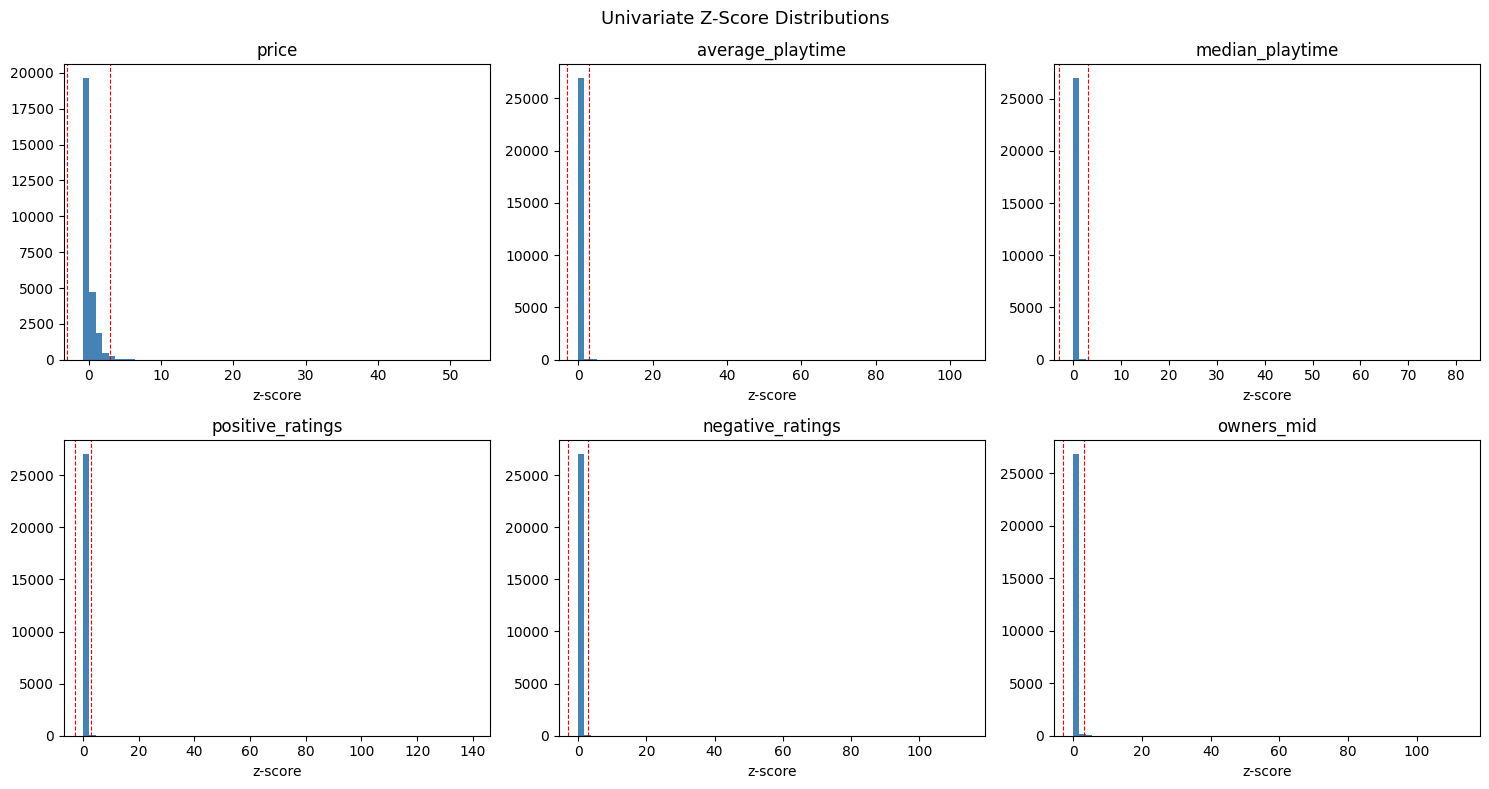


MULTIVARIATE OUTLIERS (Isolation Forest, bottom 1%)

271 games flagged

  Counter-Strike: Global Offensive          drivers: positive_ratings(z=139.2), negative_ratings(z=93.8), owners_mid(z=56.4)
  PLAYERUNKNOWN'S BATTLEGROUNDS             drivers: negative_ratings(z=113.6), owners_mid(z=56.4), positive_ratings(z=26.1)
  Grand Theft Auto V                        drivers: negative_ratings(z=32.5), positive_ratings(z=17.3), owners_mid(z=11.2)
  ARK: Survival Evolved                     drivers: negative_ratings(z=15.5), average_playtime(z=7.7), positive_ratings(z=7.6)
  MONSTER HUNTER: WORLD                     drivers: negative_ratings(z=8.2), price(z=5.6), owners_mid(z=5.5)
  Dota 2                                    drivers: owners_mid(z=112.8), positive_ratings(z=45.4), negative_ratings(z=33.1)
  The Elder Scrolls V: Skyrim               drivers: positive_ratings(z=12.4), owners_mid(z=11.2), average_playtime(z=3.8)
  Garry's Mod                               drivers: positive_ratin

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.ensemble import IsolationForest

# --- parse owners ---
def parse_owners(s):
    lo, hi = s.split('-')
    return (int(lo.replace(',', '')) + int(hi.replace(',', ''))) / 2

steam['owners_mid'] = steam['owners'].apply(parse_owners)

FEATURES = ['price', 'average_playtime', 'median_playtime',
            'positive_ratings', 'negative_ratings', 'owners_mid']

df = steam[['name'] + FEATURES].copy()

# --- outlier classification ---
def classify_outliers(values, z_scores, label):
    print(f"\n--- {label} ---")
    if len(z_scores) == 0:
        print("  No outliers flagged.")
        return

    # fit best distribution
    pos = values[values > 0]
    lognorm_params = stats.lognorm.fit(pos, floc=0)
    power_params   = stats.powerlaw.fit(pos, floc=0)
    _, ks_p_lognorm = stats.kstest(pos, 'lognorm',    args=lognorm_params)
    _, ks_p_power   = stats.kstest(pos, 'powerlaw',   args=power_params)
    if ks_p_lognorm >= ks_p_power:
        dist, params, fit_p, fit_name = stats.lognorm,   lognorm_params, ks_p_lognorm, 'log-normal'
    else:
        dist, params, fit_p, fit_name = stats.powerlaw,  power_params,   ks_p_power,   'power law'

    # data error: survival probability under fitted distribution < 1/n
    mu, sigma = values.mean(), values.std()
    outlier_vals = z_scores * sigma + mu
    pvals = 1 - dist.cdf(outlier_vals, *params)
    n_errors = (pvals < 1 / len(values)).sum()
    if n_errors:
        print(f"  Likely data errors: {n_errors} points implausible under fitted {fit_name} (p < 1/n)")

    # tail vs. cluster vs. noise
    if fit_p > 0.05:
        print(f"  Distribution fits {fit_name} (KS p={fit_p:.3f}) → outliers are expected tail")
    else:
        z_std = np.std(z_scores)
        if z_std < 1.5:
            print(f"  Outlier z-scores tightly spread (std={z_std:.2f}) → possible market cluster")
        else:
            print(f"  Outlier z-scores diffuse (std={z_std:.2f}) → likely random noise")

# =============================================================================
# 1 & 2 — Univariate z-score + classification
# =============================================================================
print("=" * 60)
print("UNIVARIATE OUTLIERS (|z| > 3)")
print("=" * 60)

z_df = pd.DataFrame(index=df.index)
for feat in FEATURES:
    z_df[feat] = stats.zscore(df[feat].fillna(0))

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flat, FEATURES):
    mask = np.abs(z_df[feat]) > 3
    outliers = df[mask][['name', feat]].copy()
    outliers['z'] = z_df.loc[mask, feat].values
    print(f"\n{feat}: {mask.sum()} outliers")
    print(outliers.sort_values('z', key=abs, ascending=False).head(10).to_string(index=False))
    classify_outliers(df[feat].values, z_df.loc[mask, feat].values, feat)
    ax.hist(z_df[feat], bins=60, color='steelblue', edgecolor='none')
    ax.axvline(3, color='red', linestyle='--', linewidth=0.8)
    ax.axvline(-3, color='red', linestyle='--', linewidth=0.8)
    ax.set_title(feat)
    ax.set_xlabel('z-score')

plt.suptitle('Univariate Z-Score Distributions', fontsize=13)
plt.tight_layout()
plt.show()

# =============================================================================
# 3 & 4 — Multivariate Isolation Forest + classification
# =============================================================================
print("\n" + "=" * 60)
print("MULTIVARIATE OUTLIERS (Isolation Forest, bottom 1%)")
print("=" * 60)

X = df[FEATURES].fillna(0)
iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_score'] = iso.fit_predict(X)
df['iso_score'] = iso.score_samples(X)   # lower = more anomalous

flagged = df[df['anomaly_score'] == -1].copy()
print(f"\n{len(flagged)} games flagged\n")

# per-game: rank features by |z| to explain the combination
z_full = pd.DataFrame(
    {feat: stats.zscore(df[feat].fillna(0)) for feat in FEATURES},
    index=df.index
)

for _, row in flagged.nsmallest(15, 'iso_score').iterrows():
    top = z_full.loc[row.name].abs().sort_values(ascending=False)
    drivers = ', '.join(f"{f}(z={z_full.loc[row.name, f]:.1f})" for f in top.index[:3])
    print(f"  {row['name'][:40]:<40}  drivers: {drivers}")

# classify the multivariate flagged set using anomaly scores as proxy signal
print()
for feat in FEATURES:
    feat_z = z_full.loc[flagged.index, feat].values
    classify_outliers(df[feat].values, feat_z, f"[multivariate] {feat}")


conclusion: there are outliers and are mostly random noise in data. owner count might have some minor error. considering this attribute is a range estimate and analysis here simply use median of the range, which might produce error, there isn't clear evidence that there are notible error in dataset.

Did free games generally receive better user ratings, or was the relationship between price and ratings more complex? 

Spearman ρ = 0.122, p = 3.184e-90
Mann-Whitney U = 29800450, p = 2.690e-05
Median rating — free: 0.735, paid: 0.765


/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_4464/3310944659.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([free, paid], labels=['free', 'paid'])


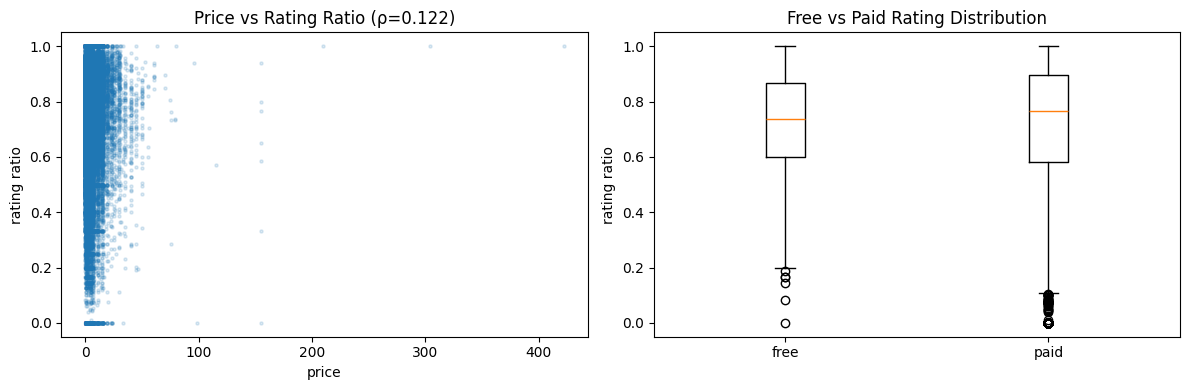

In [30]:
from scipy import stats

q2 = steam[['name', 'price', 'positive_ratings', 'negative_ratings']].copy()
q2 = q2[(q2['positive_ratings'] + q2['negative_ratings']) > 0]
q2['rating_ratio'] = q2['positive_ratings'] / (q2['positive_ratings'] + q2['negative_ratings'])

# Spearman: monotonic relationship between price and rating ratio
rho, p_spearman = stats.spearmanr(q2['price'], q2['rating_ratio'])
print(f"Spearman ρ = {rho:.3f}, p = {p_spearman:.3e}")

# Mann-Whitney U: free (price=0) vs paid
free = q2[q2['price'] == 0]['rating_ratio']
paid = q2[q2['price'] >  0]['rating_ratio']
u, p_mw = stats.mannwhitneyu(free, paid, alternative='two-sided')
print(f"Mann-Whitney U = {u:.0f}, p = {p_mw:.3e}")
print(f"Median rating — free: {free.median():.3f}, paid: {paid.median():.3f}")

# visualise
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(q2['price'], q2['rating_ratio'], alpha=0.15, s=5)
axes[0].set_xlabel('price'); axes[0].set_ylabel('rating ratio')
axes[0].set_title(f'Price vs Rating Ratio (ρ={rho:.3f})')
axes[1].boxplot([free, paid], labels=['free', 'paid'])
axes[1].set_ylabel('rating ratio')
axes[1].set_title('Free vs Paid Rating Distribution')
plt.tight_layout(); plt.show()



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


/var/folders/4s/_zql0bq16hd92_s5p_mq67480000gn/T/ipykernel_4464/2402272095.py:9: RuntimeWarning: invalid value encountered in divide
  heatmap = np.where(price_totals > 0, counts / price_totals, 0)


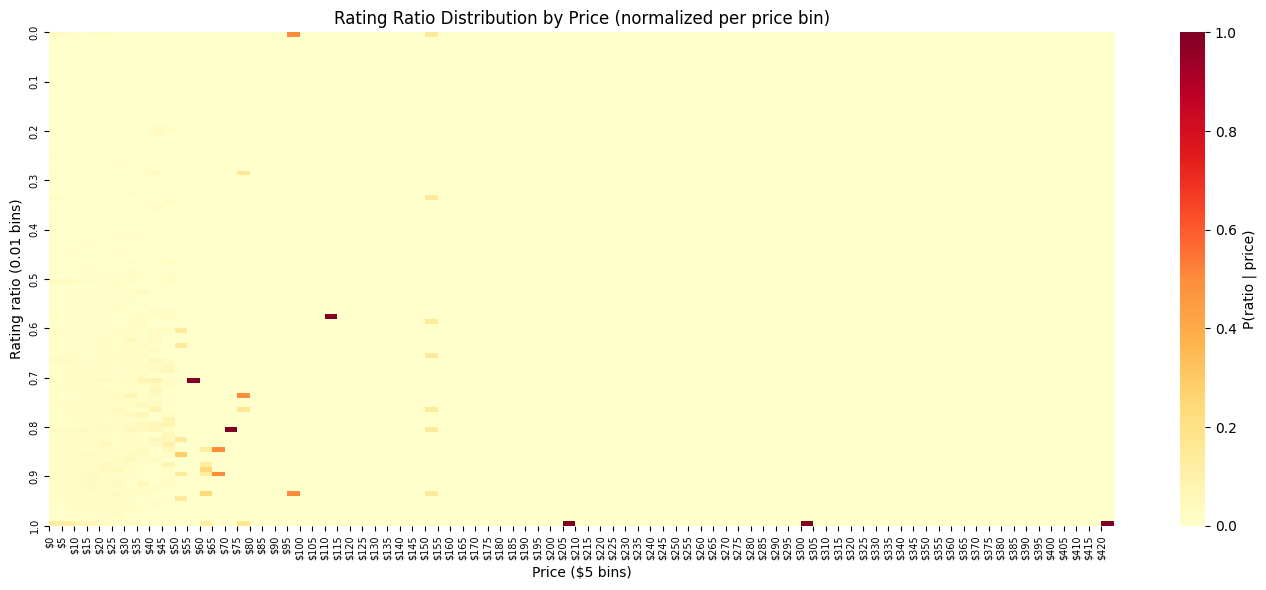

In [31]:
!pip install seaborn
import seaborn as sns

price_bins = np.arange(0, q2['price'].max() + 5, 5)
ratio_bins = np.arange(0, 1.01, 0.01)

counts, _, _ = np.histogram2d(q2['price'], q2['rating_ratio'], bins=[price_bins, ratio_bins])
price_totals = counts.sum(axis=1, keepdims=True)
heatmap = np.where(price_totals > 0, counts / price_totals, 0)

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(heatmap.T, ax=ax, cmap='YlOrRd', linewidths=0,
            cbar_kws={'label': 'P(ratio | price)'})
ax.set_xticks(np.arange(len(price_bins) - 1))
ax.set_xticklabels([f'${int(p)}' for p in price_bins[:-1]], rotation=90, fontsize=7)
ax.set_yticks(np.arange(0, 101, 10))
ax.set_yticklabels([f'{r:.1f}' for r in ratio_bins[::10]], fontsize=7)
ax.set_xlabel('Price ($5 bins)')
ax.set_ylabel('Rating ratio (0.01 bins)')
ax.set_title('Rating Ratio Distribution by Price (normalized per price bin)')
plt.tight_layout()
plt.show()


conclusion: the relation is more complex. from the first diagram, free games and very cheap games have similar and even rating distribution, and some mid-priced games have a peak of high rating. 

“More expensive games tend to keep players engaged longer.” Is this relationship robust or driven by a few blockbuster titles? If so, mentioned at least 3 blockbuster titles. 

In [32]:
from scipy import stats

q3 = steam[['name', 'price', 'average_playtime', 'owners_mid']].dropna()
q3 = q3[q3['average_playtime'] > 0]

price, playtime = q3['price'].values, q3['average_playtime'].values
rho_full, _ = stats.spearmanr(price, playtime)
print(f"Full dataset  ρ = {rho_full:.4f}  (n={len(q3)})")

# LOO influence: ρ - ρ_{-i}, positive = pulling correlation up
influence = np.array([
    rho_full - stats.spearmanr(np.delete(price, i), np.delete(playtime, i))[0]
    for i in range(len(q3))
])
q3 = q3.copy()
q3['influence'] = influence

blockbusters = q3.nlargest(15, 'influence')[['name', 'price', 'average_playtime', 'owners_mid', 'influence']]
print("\nTop influencers (blockbuster candidates):")
print(blockbusters.to_string(index=False))

# show robustness: recompute ρ after removing top k
print("\nρ after removing top-k influencers:")
idx_sorted = np.argsort(-influence)
for k in [1, 3, 5, 10, 20]:
    mask = np.ones(len(q3), dtype=bool)
    mask[idx_sorted[:k]] = False
    rho_k, _ = stats.spearmanr(price[mask], playtime[mask])
    print(f"  drop top {k:2d}: ρ = {rho_k:.4f}  (Δ = {rho_k - rho_full:+.4f})")


Full dataset  ρ = 0.2713  (n=6170)

Top influencers (blockbuster candidates):
                                 name  price  average_playtime  owners_mid  influence
                           X-Plane 11  54.99             44169    150000.0   0.000353
        Aerofly FS 2 Flight Simulator  44.99             17954     35000.0   0.000348
                ARK: Survival Evolved  44.99             14154   7500000.0   0.000346
                Football Manager 2018  37.99             19379   1500000.0   0.000345
                            Boundless  32.99             55204     35000.0   0.000345
                MONSTER HUNTER: WORLD  49.99              6512   7500000.0   0.000341
                      Fantasy Grounds  29.99             43074     35000.0   0.000339
Tales of Vesperia: Definitive Edition  34.99              9848     35000.0   0.000338
                    Hearts of Iron IV  34.99              9413   1500000.0   0.000338
                Europa Universalis IV  34.99              8138

**Conclusion:** The relationship is weak but genuinely distributed — **not driven by a few blockbusters**. The full dataset gives ρ = 0.27, and removing even the top 20 influencers only reduces it to 0.26 (Δ = −0.007), showing the correlation is stable across the board. Individual influence scores are uniformly tiny (~0.00035 each), confirming no single title is outsized. The top influencers tend to be expensive, niche titles with high playtime — **X-Plane 11** (flight sim, $55, 44k hrs), **Boundless** ($33, 55k hrs), and **ARK: Survival Evolved** ($45, 14k hrs) — but their removal barely moves the needle. So while pricier games do correlate with more playtime, the effect is modest and broad rather than a few blockbusters inflating the statistic.

Were review counts, review ratios, and ownership estimates measuring the same notion of “success,” or fundamentally different ones?

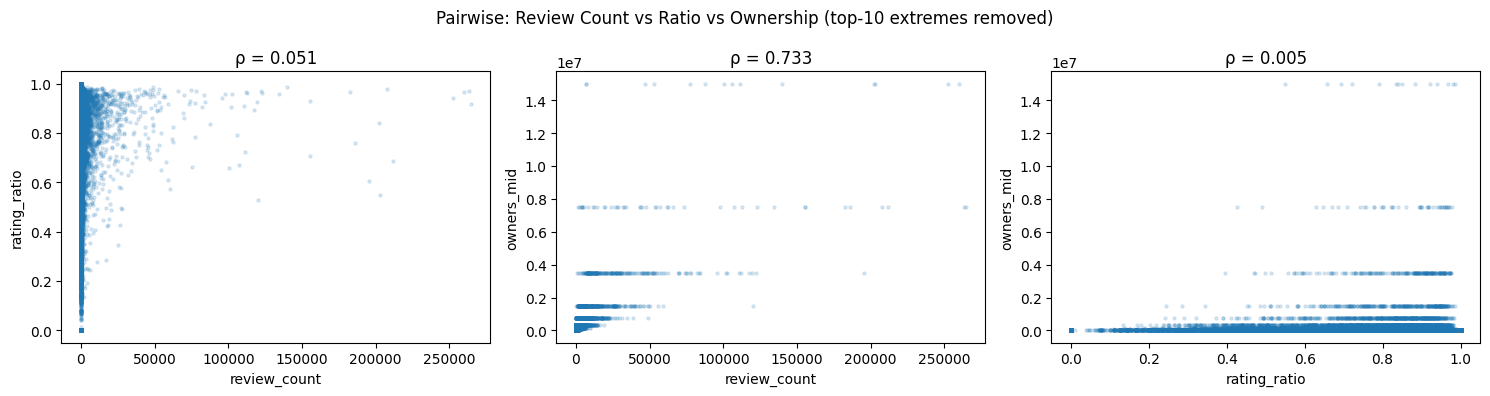

In [33]:
q4 = steam[['name', 'positive_ratings', 'negative_ratings', 'owners_mid']].dropna()
q4 = q4[(q4['positive_ratings'] + q4['negative_ratings']) > 0]
q4['review_count'] = q4['positive_ratings'] + q4['negative_ratings']
q4['rating_ratio'] = q4['positive_ratings'] / q4['review_count']

plot_features = ['review_count', 'rating_ratio', 'owners_mid']
extreme_idx = set().union(*[set(q4[f].nlargest(10).index) for f in plot_features])
q4_plot = q4.drop(index=extreme_idx)

pairs = [
    ('review_count', 'rating_ratio'),
    ('review_count', 'owners_mid'),
    ('rating_ratio', 'owners_mid'),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (x, y) in zip(axes, pairs):
    ax.scatter(q4_plot[x], q4_plot[y], alpha=0.15, s=5)
    rho, _ = stats.spearmanr(q4_plot[x], q4_plot[y])
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'ρ = {rho:.3f}')

plt.suptitle('Pairwise: Review Count vs Ratio vs Ownership (top-10 extremes removed)', fontsize=12)
plt.tight_layout()
plt.show()


conclusion: ownership estimate is mostly consistent with review count, they measure commercial success while rating ratio measure how players like the game.